
  BITCOIN (BTC) vs S&P/ASX 200 (AUSTRALIA) — IMPACT ANALYSIS

  Detected files:
    S&P/ASX 200 : /content/S&P_ASX 200 Historical Data.csv
    Bitcoin     : ./Bitcoin Historical Data_crypto.csv

  Data loaded: 87 overlapping trading days (weekends dropped)
  Period : Jan 2019 → Mar 2026

      Date  BTC_Return  ASX_Return
2019-01-01     -0.0734      0.0387
2019-02-01      0.1104      0.0519
2019-03-01      0.0749      0.0019
2019-04-01      0.2970      0.0234
2019-05-01      0.6085      0.0113
  ...

  SECTION 2 — DESCRIPTIVE STATISTICS
            Count    Mean     Std     Min     25%     50%     75%     Max
BTC_Return   87.0  0.0503  0.1894 -0.3732 -0.0714  0.0246  0.1376  0.6085
ASX_Return   87.0  0.0057  0.0436 -0.2118 -0.0140  0.0116  0.0290  0.0996

  Pearson Correlation (Bitcoin vs S&P/ASX 200): 0.4055


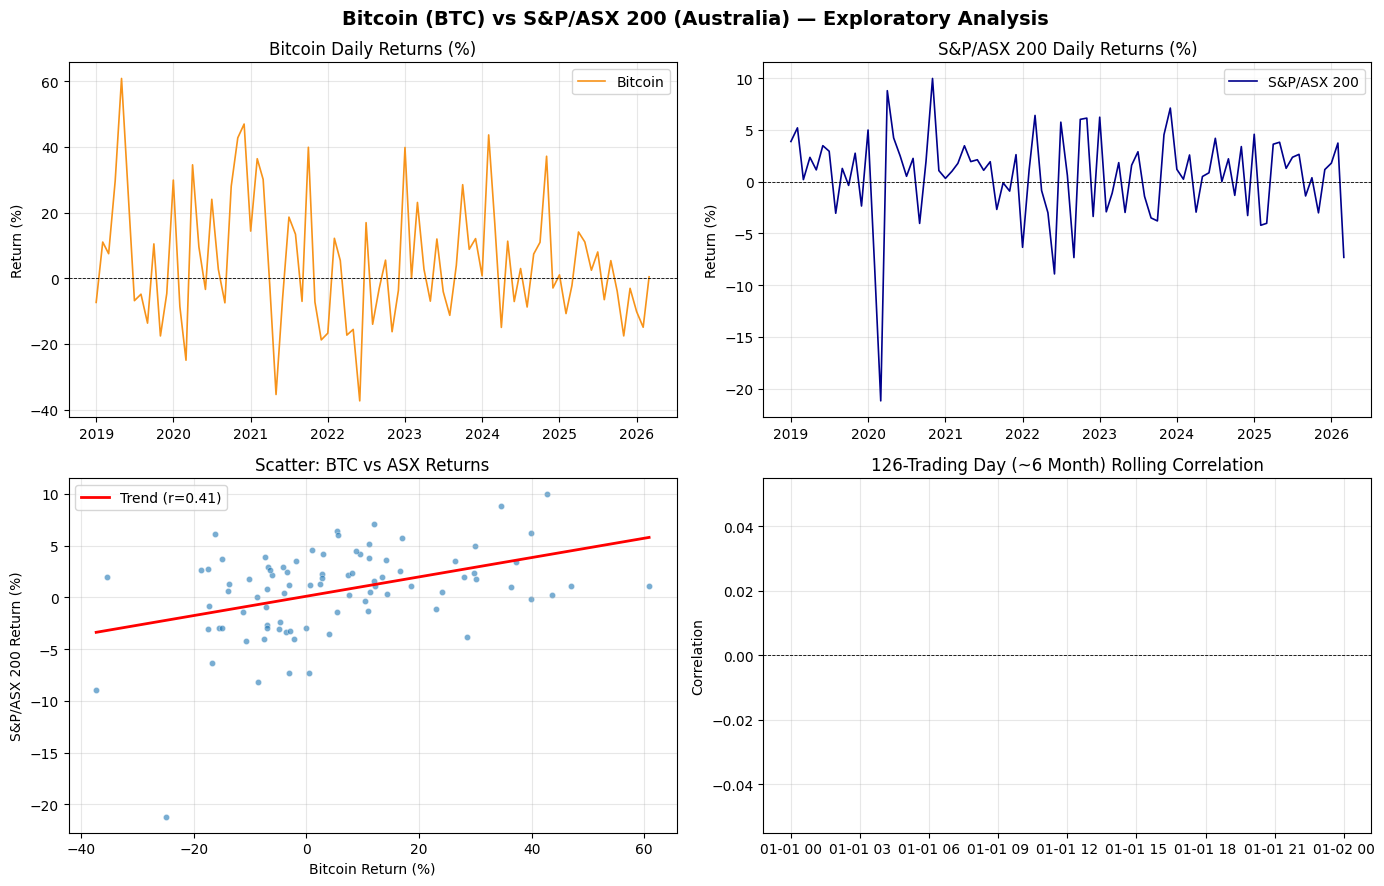


  [Chart saved: 01_exploratory_analysis.png]

  APPROACH 1 — STATIC OLS REGRESSION

  Step 3 — Means
    Average Bitcoin Return  (X̄) = 5.0294%
    Average ASX 200 Return  (Ȳ) = 0.5728%

  Step 4 — Slope β
    β = 0.0934
    → For every 1% rise in BTC, ASX changes by ~0.0934%

  Step 5 — Intercept α = 0.001032

  Step 6 — Regression Equation
    ASX_Return = 0.001032 + 0.0934 × BTC_Return

  Step 7 — t-Test for Statistical Significance
    SE(β)       = 0.0228
    t-statistic = 4.0904
    p-value     = 0.0001
    95% CI      = [0.0480, 0.1388]
    ✔ SIGNIFICANT — Reject H₀ (|t| = 4.09 > 2.0)

  Step 8 — Goodness of Fit
    R² = 0.1645  (16.45% of ASX variation explained by BTC)

  ── Full OLS Summary ──
                            OLS Regression Results                            
Dep. Variable:             ASX_Return   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statist

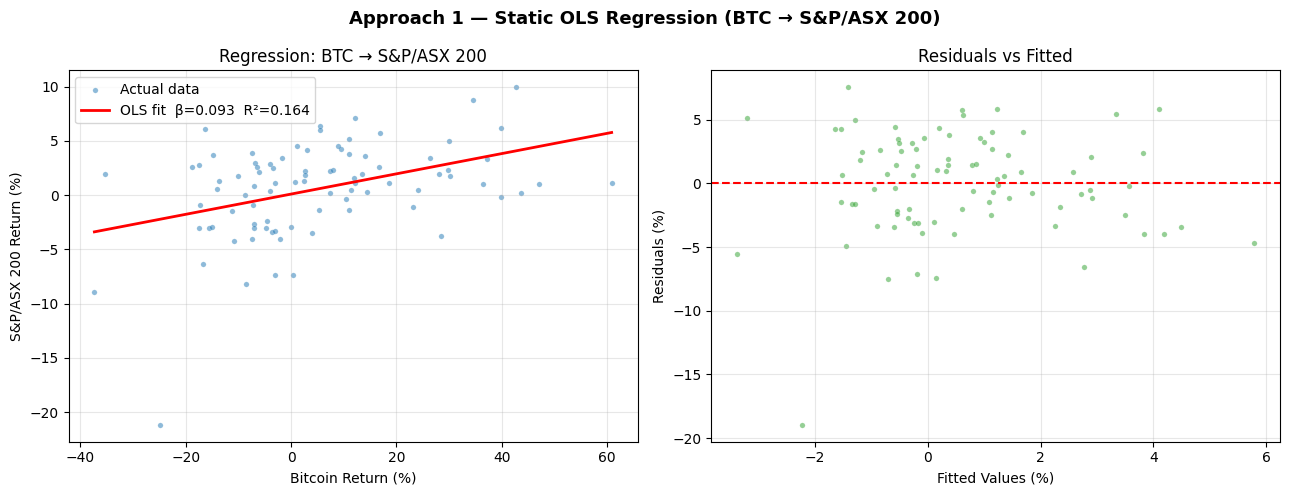


  [Chart saved: 02_approach1_static_ols.png]

  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION

  Step 2 — ADF Stationarity Test
    BTC Return                | ADF stat =  -7.390 | p = 0.0000 | ✔ Stationary
    S&P/ASX 200 Return        | ADF stat =  -8.671 | p = 0.0000 | ✔ Stationary

  Step 3 — Autocorrelation of ASX Returns
    Lag-1 autocorrelation: -0.0821
    Lag-2 autocorrelation: -0.2463
    Low autocorrelation — lagged term adds robustness

  Step 4 & 5 — Building Dynamic Regression Model
    Model: ASX_t = α + β×BTC_t + γ×ASX_(t-1)

    Estimated equation:
    ASX_t = 0.00048 + 0.0949×BTC_t + -0.0069×ASX_(t-1)

  Step 6 — Statistical Significance
    Crypto effect (β): coef=0.0949  t=4.059  p=0.0001  ✔ Significant
    Lag effect   (γ): coef=-0.0069  t=-0.067  p=0.9471  ✘ Not significant

    R² (dynamic model) = 0.1713
    Adj. R²            = 0.1513

  Step 7 — Granger Causality Test
    H₀: BTC returns do NOT Granger-cause S&P/ASX 200 returns
    Sample size: 87 obs → testin

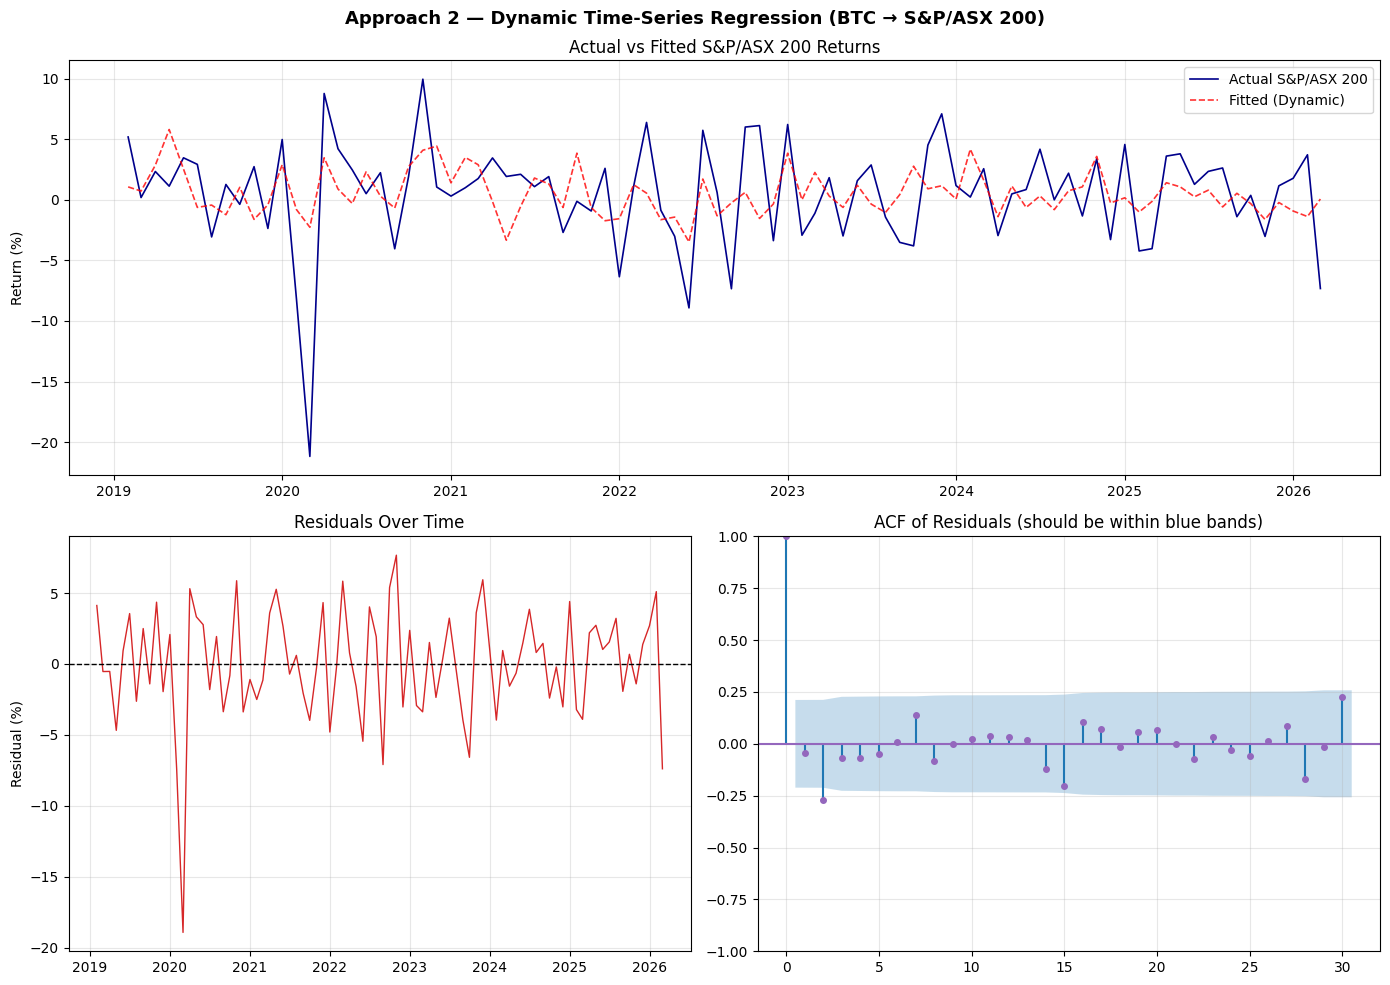


  [Chart saved: 03_approach2_dynamic.png]

  FINAL COMPARISON SUMMARY
                     Approach 1 (Static)      Approach 2 (Dynamic)
Method                    OLS Regression  Dynamic Regression + Lag
Crypto Coeff (β)                  0.0934                    0.0949
Lag Term (γ)                Not included                   -0.0069
p-value (crypto)                  0.0001                    0.0001
R²                                0.1645                    0.1713
Accounts for Memory?                  No                       Yes


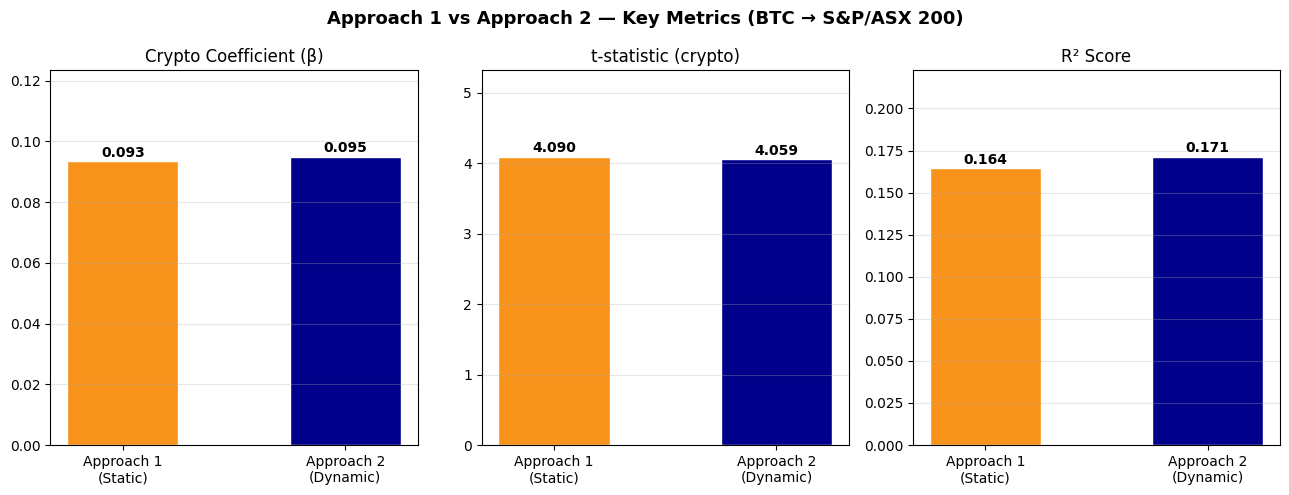


  [Chart saved: 04_comparison_summary.png]

  CONCLUSION & ECONOMETRIC CONSIDERATIONS

  Analysis of Bitcoin (BTC) impact on S&P/ASX 200 Index (Australia):

  ▸ Approach 1 (Static OLS):
      β = 0.0934 — a 1% BTC change correlates with ~0.093% ASX change
      R² = 0.1645
      Result: SIGNIFICANT

  ▸ Approach 2 (Dynamic with Lag):
      β = 0.0949 — immediate effect after controlling for momentum
      γ = -0.0069 — -0.7% of prior period's ASX return persists
      R² = 0.1713
      Result: SIGNIFICANT

  CRITICAL LOGICAL CONSIDERATIONS FOR AUSTRALIA:
  1. The "Barbell" Economy: The S&P/ASX 200 is heavily concentrated in massive 
     legacy banks (Financials) and global mining conglomerates (Materials, like BHP 
     and Rio Tinto). These traditional mega-caps are driven by domestic lending 
     rates and iron ore exports to China, completely isolated from Bitcoin volatility.
  2. High Retail Overlap & Liquidity Rotation: Despite the legacy index, Australians 
     have one of th

In [ ]:
# ============================================================
#   BITCOIN (BTC) vs S&P/ASX 200 (AUSTRALIA) — IMPACT ANALYSIS
# ============================================================

import subprocess
subprocess.run(["pip", "install", "statsmodels", "scipy", "pandas", "numpy", "matplotlib", "-q"])

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# AUTO-DETECT UPLOADED CSV FILES
# ============================================================


search_dirs = ["/content", "/root", "."]
csv_files = []
for d in search_dirs:
    csv_files.extend(glob.glob(os.path.join(d, "*.csv")))

csv_files = list(set(csv_files))

if len(csv_files) < 2:
    raise FileNotFoundError(
        f"Found only {len(csv_files)} CSV file(s). "
        "Please ensure both ASX 200 and Bitcoin CSV files are present in the Colab session "
        "before running this script (use the file browser on the left sidebar)."
    )


ASX_FILE = next((f for f in csv_files if "ASX" in os.path.basename(f).upper() or "200" in os.path.basename(f)), None)
BTC_FILE = next((f for f in csv_files if "Bitcoin" in os.path.basename(f) or "bitcoin" in os.path.basename(f)
                                         or "crypto" in os.path.basename(f) or "BTC" in os.path.basename(f)), None)


if ASX_FILE is None or BTC_FILE is None:
    remaining = [f for f in csv_files if f not in (ASX_FILE, BTC_FILE)]
    if ASX_FILE is None and remaining:
        ASX_FILE = remaining.pop(0)
    if BTC_FILE is None and remaining:
        BTC_FILE = remaining.pop(0)

if ASX_FILE is None or BTC_FILE is None:
    raise FileNotFoundError(
        "Could not identify both ASX 200 and Bitcoin CSV files. "
        f"Files found: {csv_files}\n"
        "Please ensure filenames contain 'ASX' and 'Bitcoin'/'crypto'."
    )

print("\n" + "=" * 65)
print("  BITCOIN (BTC) vs S&P/ASX 200 (AUSTRALIA) — IMPACT ANALYSIS")
print("=" * 65)
print(f"\n  Detected files:")
print(f"    S&P/ASX 200 : {ASX_FILE}")
print(f"    Bitcoin     : {BTC_FILE}")

# ============================================================
# DATA LOADING & CLEANING
# ============================================================

def load_and_clean(filepath, label):
    df = pd.read_csv(filepath, thousands=",")
    df.columns = df.columns.str.strip()

    df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False)
    df = df.sort_values("Date").reset_index(drop=True)

    # --------------------------------------------------------
    # Strip commas out of the percentages/strings
    # --------------------------------------------------------
    df["Return"] = (
        df["Change %"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype(float)
        / 100
    )
    df = df[["Date", "Return"]].rename(columns={"Return": label})
    return df

btc = load_and_clean(BTC_FILE, "BTC_Return")
asx = load_and_clean(ASX_FILE, "ASX_Return")

data = pd.merge(btc, asx, on="Date", how="inner")
data = data.sort_values("Date").dropna().reset_index(drop=True)

print(f"\n  Data loaded: {len(data)} overlapping trading days (weekends dropped)")
print(f"  Period : {data['Date'].min().strftime('%b %Y')} → {data['Date'].max().strftime('%b %Y')}\n")
print(data[["Date", "BTC_Return", "ASX_Return"]].head().to_string(index=False))
print("  ...")

# ============================================================
# SECTION 2: DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 65)
print("  SECTION 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)

desc = data[["BTC_Return", "ASX_Return"]].describe().T
desc.columns = ["Count", "Mean", "Std", "Min", "25%", "50%", "75%", "Max"]
print(desc.round(4).to_string())

corr = data["BTC_Return"].corr(data["ASX_Return"])
print(f"\n  Pearson Correlation (Bitcoin vs S&P/ASX 200): {corr:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Bitcoin (BTC) vs S&P/ASX 200 (Australia) — Exploratory Analysis", fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.plot(data["Date"], data["BTC_Return"] * 100, color="#F7931A", label="Bitcoin", linewidth=1.2) # Bitcoin Orange
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("Bitcoin Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(data["Date"], data["ASX_Return"] * 100, color="#00008B", label="S&P/ASX 200", linewidth=1.2) # Dark Blue
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("S&P/ASX 200 Daily Returns (%)")
ax.set_ylabel("Return (%)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(data["BTC_Return"] * 100, data["ASX_Return"] * 100,
           alpha=0.6, color="#1f77b4", edgecolors="white", linewidth=0.4, s=20)
m, b = np.polyfit(data["BTC_Return"], data["ASX_Return"], 1)
x_line = np.linspace(data["BTC_Return"].min(), data["BTC_Return"].max(), 100)
ax.plot(x_line * 100, (m * x_line + b) * 100, color="red", linewidth=2, label=f"Trend (r={corr:.2f})")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("S&P/ASX 200 Return (%)")
ax.set_title("Scatter: BTC vs ASX Returns")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]

roll_corr = data["BTC_Return"].rolling(126).corr(data["ASX_Return"])
ax.plot(data["Date"], roll_corr, color="#00008B", linewidth=1.8)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title("126-Trading Day (~6 Month) Rolling Correlation")
ax.set_ylabel("Correlation")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 01_exploratory_analysis.png]")

# ============================================================
# APPROACH 1: STATIC OLS REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 1 — STATIC OLS REGRESSION")
print("=" * 65)

X = data["BTC_Return"]
Y = data["ASX_Return"]

x_mean = X.mean()
y_mean = Y.mean()
print(f"\n  Step 3 — Means")
print(f"    Average Bitcoin Return  (X̄) = {x_mean*100:.4f}%")
print(f"    Average ASX 200 Return  (Ȳ) = {y_mean*100:.4f}%")

numerator   = ((X - x_mean) * (Y - y_mean)).sum()
denominator = ((X - x_mean) ** 2).sum()
beta        = numerator / denominator
print(f"\n  Step 4 — Slope β")
print(f"    β = {beta:.4f}")
print(f"    → For every 1% rise in BTC, ASX changes by ~{beta:.4f}%")

alpha = y_mean - beta * x_mean
print(f"\n  Step 5 — Intercept α = {alpha:.6f}")

print(f"\n  Step 6 — Regression Equation")
print(f"    ASX_Return = {alpha:.6f} + {beta:.4f} × BTC_Return")

X_const   = sm.add_constant(X)
ols_model = sm.OLS(Y, X_const).fit()
se_beta   = ols_model.bse["BTC_Return"]
t_stat    = ols_model.tvalues["BTC_Return"]
p_value   = ols_model.pvalues["BTC_Return"]
ci        = ols_model.conf_int().loc["BTC_Return"]

print(f"\n  Step 7 — t-Test for Statistical Significance")
print(f"    SE(β)       = {se_beta:.4f}")
print(f"    t-statistic = {t_stat:.4f}")
print(f"    p-value     = {p_value:.4f}")
print(f"    95% CI      = [{ci[0]:.4f}, {ci[1]:.4f}]")
if abs(t_stat) > 2.0:
    print(f"    ✔ SIGNIFICANT — Reject H₀ (|t| = {t_stat:.2f} > 2.0)")
else:
    print(f"    ✘ NOT significant — Fail to reject H₀")

r_squared = ols_model.rsquared
print(f"\n  Step 8 — Goodness of Fit")
print(f"    R² = {r_squared:.4f}  ({r_squared*100:.2f}% of ASX variation explained by BTC)")

print(f"\n  ── Full OLS Summary ──")
print(ols_model.summary())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Approach 1 — Static OLS Regression (BTC → S&P/ASX 200)", fontsize=13, fontweight="bold")

ax = axes[0]
ax.scatter(X * 100, Y * 100, alpha=0.5, color="#1f77b4", edgecolors="white", linewidth=0.2, s=15, label="Actual data")
x_fit = np.linspace(X.min(), X.max(), 200)
y_fit = alpha + beta * x_fit
ax.plot(x_fit * 100, y_fit * 100, color="red", linewidth=2, label=f"OLS fit  β={beta:.3f}  R²={r_squared:.3f}")
ax.set_xlabel("Bitcoin Return (%)")
ax.set_ylabel("S&P/ASX 200 Return (%)")
ax.set_title("Regression: BTC → S&P/ASX 200")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
residuals = ols_model.resid
ax.scatter(ols_model.fittedvalues * 100, residuals * 100, alpha=0.5, color="#2ca02c", edgecolors="white", linewidth=0.2, s=15)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residuals vs Fitted")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_approach1_static_ols.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 02_approach1_static_ols.png]")

# ============================================================
# APPROACH 2: DYNAMIC TIME-SERIES REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("  APPROACH 2 — DYNAMIC TIME-SERIES REGRESSION")
print("=" * 65)

print("\n  Step 2 — ADF Stationarity Test")
for series, name in [(data["BTC_Return"], "BTC Return"),
                     (data["ASX_Return"], "S&P/ASX 200 Return")]:
    adf_result = adfuller(series.dropna())
    stat, pval = adf_result[0], adf_result[1]
    flag = "✔ Stationary" if pval < 0.05 else "⚠ Non-Stationary"
    print(f"    {name:25s} | ADF stat = {stat:7.3f} | p = {pval:.4f} | {flag}")

print("\n  Step 3 — Autocorrelation of ASX Returns")
lag1_autocorr = data["ASX_Return"].autocorr(lag=1)
lag2_autocorr = data["ASX_Return"].autocorr(lag=2)
print(f"    Lag-1 autocorrelation: {lag1_autocorr:.4f}")
print(f"    Lag-2 autocorrelation: {lag2_autocorr:.4f}")
if abs(lag1_autocorr) > 0.1:
    print("    ⚠ Notable autocorrelation — lagged term is essential for model validity")
else:
    print("    Low autocorrelation — lagged term adds robustness")

print("\n  Step 4 & 5 — Building Dynamic Regression Model")
print("    Model: ASX_t = α + β×BTC_t + γ×ASX_(t-1)")

data_dyn = data.copy()
data_dyn["ASX_Lag1"] = data_dyn["ASX_Return"].shift(1)
data_dyn = data_dyn.dropna().reset_index(drop=True)

Y_dyn = data_dyn["ASX_Return"]
X_dyn = sm.add_constant(data_dyn[["BTC_Return", "ASX_Lag1"]])

dyn_model = sm.OLS(Y_dyn, X_dyn).fit()

alpha_dyn = dyn_model.params["const"]
beta_dyn  = dyn_model.params["BTC_Return"]
gamma_dyn = dyn_model.params["ASX_Lag1"]

print(f"\n    Estimated equation:")
print(f"    ASX_t = {alpha_dyn:.5f} + {beta_dyn:.4f}×BTC_t + {gamma_dyn:.4f}×ASX_(t-1)")

print(f"\n  Step 6 — Statistical Significance")
for var in ["BTC_Return", "ASX_Lag1"]:
    t  = dyn_model.tvalues[var]
    p  = dyn_model.pvalues[var]
    ci = dyn_model.conf_int().loc[var]
    label = "Crypto effect (β)" if var == "BTC_Return" else "Lag effect   (γ)"
    sig = "✔ Significant" if p < 0.05 else "✘ Not significant"
    print(f"    {label}: coef={dyn_model.params[var]:.4f}  t={t:.3f}  p={p:.4f}  {sig}")

print(f"\n    R² (dynamic model) = {dyn_model.rsquared:.4f}")
print(f"    Adj. R²            = {dyn_model.rsquared_adj:.4f}")

print("\n  Step 7 — Granger Causality Test")
print("    H₀: BTC returns do NOT Granger-cause S&P/ASX 200 returns")
granger_data = data[["ASX_Return", "BTC_Return"]].dropna()
max_allowable_lag = max(1, int((len(granger_data) - 1) / 3) - 1)
granger_maxlag    = min(5, max_allowable_lag)
print(f"    Sample size: {len(granger_data)} obs → testing up to lag={granger_maxlag} days")
gc_results = grangercausalitytests(granger_data, maxlag=granger_maxlag, verbose=False)

for lag, res in gc_results.items():
    f_stat = res[0]["ssr_ftest"][0]
    p_gc   = res[0]["ssr_ftest"][1]
    flag   = "✔ Granger-causes" if p_gc < 0.05 else "✘ No causal effect"
    print(f"    Lag {lag} day(s): F={f_stat:.3f}  p={p_gc:.4f}  → {flag}")

print("\n  Step 8 — Diagnostic Checks")
dw_stat = durbin_watson(dyn_model.resid)
print(f"    Durbin-Watson statistic = {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("    ✔ No significant autocorrelation in residuals (DW ≈ 2.0)")
else:
    print("    ⚠ Possible residual autocorrelation detected")

print(f"\n  ── Full Dynamic Model Summary ──")
print(dyn_model.summary())

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Approach 2 — Dynamic Time-Series Regression (BTC → S&P/ASX 200)", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(data_dyn["Date"], Y_dyn * 100, color="#00008B", linewidth=1.2, label="Actual S&P/ASX 200")
ax1.plot(data_dyn["Date"], dyn_model.fittedvalues * 100, color="red", linestyle="--", linewidth=1.2, alpha=0.8, label="Fitted (Dynamic)")
ax1.set_title("Actual vs Fitted S&P/ASX 200 Returns")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(data_dyn["Date"], dyn_model.resid * 100, color="#d62728", linewidth=1.0)
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_title("Residuals Over Time")
ax2.set_ylabel("Residual (%)")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
acf_lags = min(30, len(dyn_model.resid) // 2 - 1)
plot_acf(dyn_model.resid, lags=acf_lags, ax=ax3, color="#9467bd", markersize=4)
ax3.set_title("ACF of Residuals (should be within blue bands)")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_approach2_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 03_approach2_dynamic.png]")

# ============================================================
# FINAL SUMMARY & ECONOMETRIC CONSIDERATIONS
# ============================================================

print("\n" + "=" * 65)
print("  FINAL COMPARISON SUMMARY")
print("=" * 65)

summary = {
    "Method"               : ["OLS Regression", "Dynamic Regression + Lag"],
    "Crypto Coeff (β)"     : [f"{beta:.4f}", f"{beta_dyn:.4f}"],
    "Lag Term (γ)"         : ["Not included", f"{gamma_dyn:.4f}"],
    "p-value (crypto)"     : [f"{p_value:.4f}", f"{dyn_model.pvalues['BTC_Return']:.4f}"],
    "R²"                   : [f"{ols_model.rsquared:.4f}", f"{dyn_model.rsquared:.4f}"],
    "Accounts for Memory?" : ["No", "Yes"],
}
summary_df = pd.DataFrame(summary, index=["Approach 1 (Static)", "Approach 2 (Dynamic)"]).T
print(summary_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Approach 1 vs Approach 2 — Key Metrics (BTC → S&P/ASX 200)", fontsize=13, fontweight="bold")

metrics = {
    "Crypto Coefficient (β)": (beta, beta_dyn),
    "t-statistic (crypto)"  : (t_stat, dyn_model.tvalues["BTC_Return"]),
    "R² Score"              : (ols_model.rsquared, dyn_model.rsquared),
}
colors = ["#F7931A", "#00008B"]

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["Approach 1\n(Static)", "Approach 2\n(Dynamic)"],
                  vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005 * max(abs(v) for v in vals),
                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)

    y_min, y_max = min(vals), max(vals)
    padding = max(abs(y_min), abs(y_max)) * 0.3
    ax.set_ylim(y_min - padding if y_min < 0 else 0, y_max + padding)

plt.tight_layout()
plt.savefig("04_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Chart saved: 04_comparison_summary.png]")

sig1 = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
sig2 = "SIGNIFICANT" if dyn_model.pvalues['BTC_Return'] < 0.05 else "NOT SIGNIFICANT"

print("\n" + "=" * 65)
print("  CONCLUSION & ECONOMETRIC CONSIDERATIONS")
print("=" * 65)
print(f"""
  Analysis of Bitcoin (BTC) impact on S&P/ASX 200 Index (Australia):

  ▸ Approach 1 (Static OLS):
      β = {beta:.4f} — a 1% BTC change correlates with ~{beta:.3f}% ASX change
      R² = {ols_model.rsquared:.4f}
      Result: {sig1}

  ▸ Approach 2 (Dynamic with Lag):
      β = {beta_dyn:.4f} — immediate effect after controlling for momentum
      γ = {gamma_dyn:.4f} — {gamma_dyn*100:.1f}% of prior period's ASX return persists
      R² = {dyn_model.rsquared:.4f}
      Result: {sig2}

  CRITICAL LOGICAL CONSIDERATIONS FOR AUSTRALIA:
  1. The "Barbell" Economy: The S&P/ASX 200 is heavily concentrated in massive
     legacy banks (Financials) and global mining conglomerates (Materials, like BHP
     and Rio Tinto). These traditional mega-caps are driven by domestic lending
     rates and iron ore exports to China, completely isolated from Bitcoin volatility.
  2. High Retail Overlap & Liquidity Rotation: Despite the legacy index, Australians
     have one of the highest per-capita rates of retail crypto adoption globally.
     When global liquidity is high ("Risk-On"), Australian investors tend to bid up
     both tech/micro-cap stocks on the ASX and cryptocurrencies simultaneously.
  3. AUD Currency Stability: Unlike emerging markets experiencing hyperinflation,
     the Australian Dollar (AUD) is a stable, free-floating G10 currency. If the
     models show any significant correlation, it is a genuine reflection of shared
     investor sentiment and global liquidity cycles (like US Federal Reserve policies),
     rather than an illusion caused by local currency collapse.
""")
print("=" * 65)
print("  Analysis complete. All 4 charts saved as PNG files.")
print("=" * 65)